In [278]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

summary_path = Path("/Users/bigrorz/UnityProjects/MultipleStyleRendering/ProfilingLogs/summary.csv")

df = pd.read_csv(summary_path)

# clean strings
df["render_mode"] = df["render_mode"].astype(str).str.strip()
df["test_name"] = df["test_name"].astype(str).str.strip()

# ensure numerics
numeric_cols = [
    "value", "N", "K", "styles_per_object",
    "mean_cpu_ms", "median_cpu_ms", "p95_cpu_ms", "p99_cpu_ms", "max_cpu_ms", "std_cpu_ms",
    "mean_gpu_ms", "median_gpu_ms", "p95_gpu_ms", "p99_gpu_ms", "max_gpu_ms", "std_gpu_ms"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

METHODS = {"CPU", "GPU", "Fullscreen", "Tiling"}

def parse_ablation_fields(test_name: str):
    tokens = str(test_name).split("_")

    result = {
        "base_test_name": None,
        "merge": None,         # True / False / None
        "occlusion": None,     # True / False / None
        "style_variant": None, # optional helper
        "shader_variant": "Default",
    }

    # heavy
    if "Heavy" in tokens:
        result["shader_variant"] = "Heavy"
        tokens.remove("Heavy")

    # style variant helper
    if "RandomSingleStyle" in tokens:
        result["style_variant"] = "RandomSingleStyle"
        tokens.remove("RandomSingleStyle")
    elif "SameStyle" in tokens:
        result["style_variant"] = "SameStyle"
        tokens.remove("SameStyle")

    # ablations
    if "NoMerge" in tokens:
        result["merge"] = False
        tokens.remove("NoMerge")
    elif "Merge" in tokens:
        result["merge"] = True
        tokens.remove("Merge")

    if "NoOcclusion" in tokens:
        result["occlusion"] = False
        tokens.remove("NoOcclusion")
    elif "Occlusion" in tokens:
        result["occlusion"] = True
        tokens.remove("Occlusion")

    result["base_test_name"] = "_".join(tokens)
    return result


parsed = df["test_name"].apply(parse_ablation_fields).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)

def make_merge_label(row):
    if row["merge"] is True:
        return "Merge"
    if row["merge"] is False:
        return "NoMerge"
    return None

def make_occlusion_label(row):
    if row["occlusion"] is True:
        return "Occlusion"
    if row["occlusion"] is False:
        return "NoOcclusion"
    return None

df["merge_label"] = df.apply(make_merge_label, axis=1)
df["occlusion_label"] = df.apply(make_occlusion_label, axis=1)

display(df[[
    "test_name", "base_test_name", "render_mode",
    "merge", "merge_label", "occlusion", "occlusion_label"
]])

# show one of each testname
# display(df.drop_duplicates(subset=["test_name"])[[
#     "test_name", "base_test_name", "render_mode",
#     "merge", "merge_label", "occlusion", "occlusion_label"
# ]])

,test_name,base_test_name,render_mode,merge,merge_label,occlusion,occlusion_label
0,AreaScaling,AreaScaling,Fullscreen,NaN,NaN,NaN,NaN
1,AreaScaling,AreaScaling,CPU,NaN,NaN,NaN,NaN
2,AreaScaling,AreaScaling,GPU,NaN,NaN,NaN,NaN
3,AreaScaling,AreaScaling,Fullscreen,NaN,NaN,NaN,NaN
4,AreaScaling,AreaScaling,CPU,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
908,BBoxCountScaling_RandomSingleStyle_Tiling64,BBoxCountScaling_Tiling64,Tiling,NaN,NaN,NaN,NaN
909,BBoxCountScaling_RandomSingleStyle_Tiling64,BBoxCountScaling_Tiling64,Tiling,NaN,NaN,NaN,NaN
910,BBoxCountScaling_RandomSingleStyle_Tiling64,BBoxCountScaling_Tiling64,Tiling,NaN,NaN,NaN,NaN
911,BBoxCountScaling_RandomSingleStyle_Tiling64,BBoxCountScaling_Tiling64,Tiling,NaN,NaN,NaN,NaN


In [281]:
def plot_method_graph(
    df,
    family,
    variable,
    metric="gpu",
    methods=("Fullscreen", "CPU", "GPU", "Tiling"),
    style_variant=None,
    title=None,
):
    local_df = df.copy()

    local_df["method_family"] = (
        local_df["base_test_name"]
        .astype(str)
        .str.replace(r"_Tiling$", "", regex=True)
        .str.replace(r"_CPU$", "", regex=True)
        .str.replace(r"_GPU$", "", regex=True)
    )

    subset = local_df[
        (local_df["method_family"] == family) &
        (local_df["variable"] == variable) &
        (local_df["merge"].isna()) &
        (local_df["occlusion"].isna())
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if subset.empty:
        print(
            f"No baseline method-comparison data for "
            f"family='{family}', variable='{variable}', style_variant='{style_variant}'."
        )
        return

    subset = (
        subset
        .groupby(["value", "render_mode"], as_index=False)
        .agg({
            f"median_{metric}_ms": "median",
            f"p95_{metric}_ms": "median"
        })
        .sort_values(["value", "render_mode"])
    )

    plt.figure(figsize=(9, 5))

    for method in methods:
        mode_df = subset[subset["render_mode"] == method].sort_values("value")
        if mode_df.empty:
            continue

        x = mode_df["value"].values
        median = mode_df[f"median_{metric}_ms"].values
        p95 = mode_df[f"p95_{metric}_ms"].values

        lower_err = np.zeros_like(median)
        upper_err = p95 - median

        plt.errorbar(
            x,
            median,
            yerr=[lower_err, upper_err],
            marker="o",
            capsize=4,
            label=method
        )

    plt.axhline(16.67, linestyle="--", linewidth=1, label="60 FPS")
    plt.axhline(33.33, linestyle="--", linewidth=1, label="30 FPS")

    if title is None:
        variant_str = f" ({style_variant})" if style_variant is not None else ""
        title = f"{family}{variant_str}: {metric.upper()} Frame Time vs {variable} (Median + P95 Error)"

    plt.title(title)
    plt.xlabel(variable)
    plt.ylabel("Frame time (ms)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_method_graph_row(
    df,
    family,
    variable,
    methods=("Fullscreen", "CPU", "GPU", "Tiling"),
    style_variant=None,
    title_prefix=None,
):
    local_df = df.copy()

    local_df["method_family"] = (
        local_df["base_test_name"]
        .astype(str)
        .str.replace(r"_Tiling$", "", regex=True)
        .str.replace(r"_CPU$", "", regex=True)
        .str.replace(r"_GPU$", "", regex=True)
    )

    subset = local_df[
        (local_df["method_family"] == family) &
        (local_df["variable"] == variable) &
        (local_df["merge"].isna()) &
        (local_df["occlusion"].isna())
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if subset.empty:
        print(
            f"No baseline method-comparison data for "
            f"family='{family}', variable='{variable}', style_variant='{style_variant}'."
        )
        return

    subset = (
        subset
        .groupby(["value", "render_mode"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "render_mode"])
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    panels = [
        ("cpu", "CPU Frame Time"),
        ("gpu", "GPU Frame Time"),
        ("bottleneck", "Bottleneck Frame Time"),
    ]

    for ax, (metric, panel_title) in zip(axes, panels):
        for method in methods:
            mode_df = subset[subset["render_mode"] == method].sort_values("value")
            if mode_df.empty:
                continue

            x = mode_df["value"].values

            if metric == "cpu":
                median = mode_df["median_cpu_ms"].values
                p95 = mode_df["p95_cpu_ms"].values

            elif metric == "gpu":
                median = mode_df["median_gpu_ms"].values
                p95 = mode_df["p95_gpu_ms"].values

            else:
                cpu_med = mode_df["median_cpu_ms"].values
                gpu_med = mode_df["median_gpu_ms"].values
                cpu_p95 = mode_df["p95_cpu_ms"].values
                gpu_p95 = mode_df["p95_gpu_ms"].values

                median = np.maximum(cpu_med, gpu_med)
                p95 = np.maximum(cpu_p95, gpu_p95)

            lower_err = np.zeros_like(median)
            upper_err = p95 - median

            ax.errorbar(
                x,
                median,
                yerr=[lower_err, upper_err],
                marker="o",
                capsize=4,
                label=method
            )

        ax.axhline(16.67, linestyle="--", linewidth=1, label="60 FPS")
        ax.axhline(33.33, linestyle="--", linewidth=1, label="30 FPS")
        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("Frame time (ms)")
        ax.grid(True, alpha=0.3)

    if title_prefix is None:
        title_prefix = family

    if style_variant is not None:
        title_prefix = f"{title_prefix} ({style_variant})"

    fig.suptitle(f"{title_prefix}: Method Comparison", y=1.02, fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.08))
    plt.tight_layout()
    plt.show()

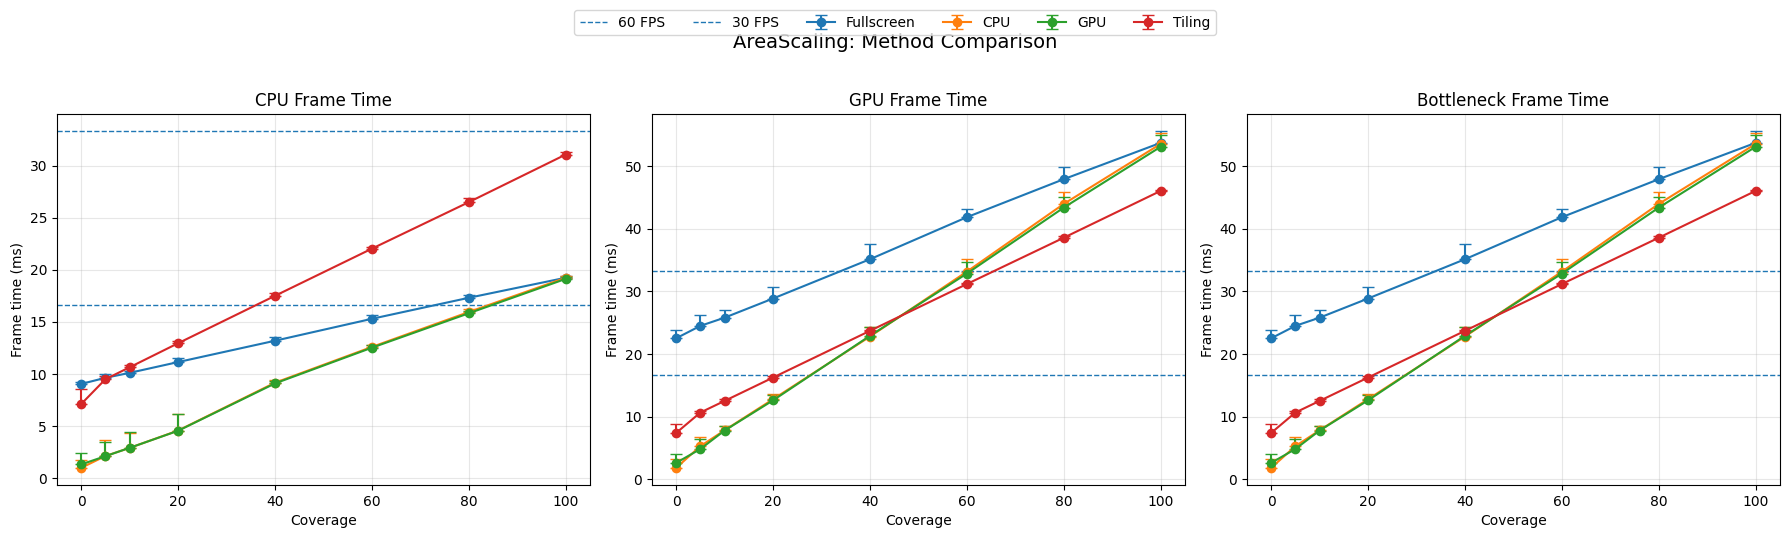

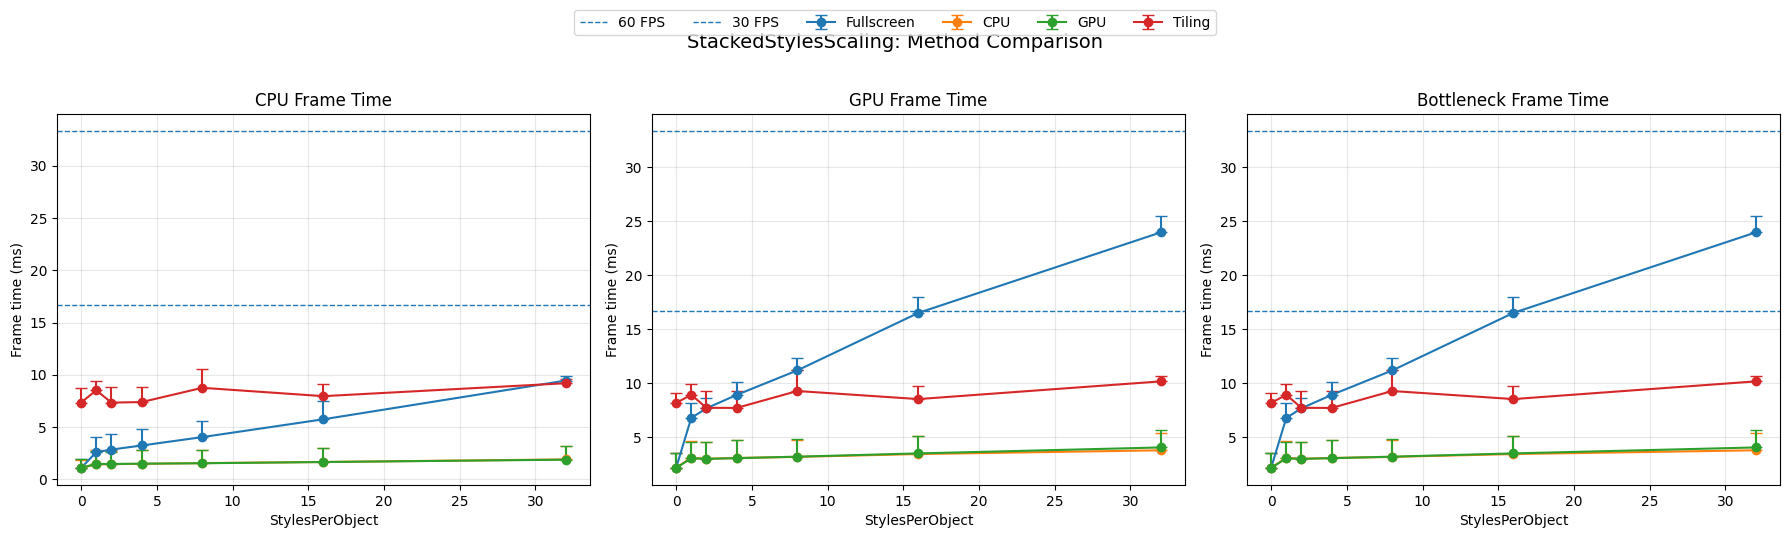

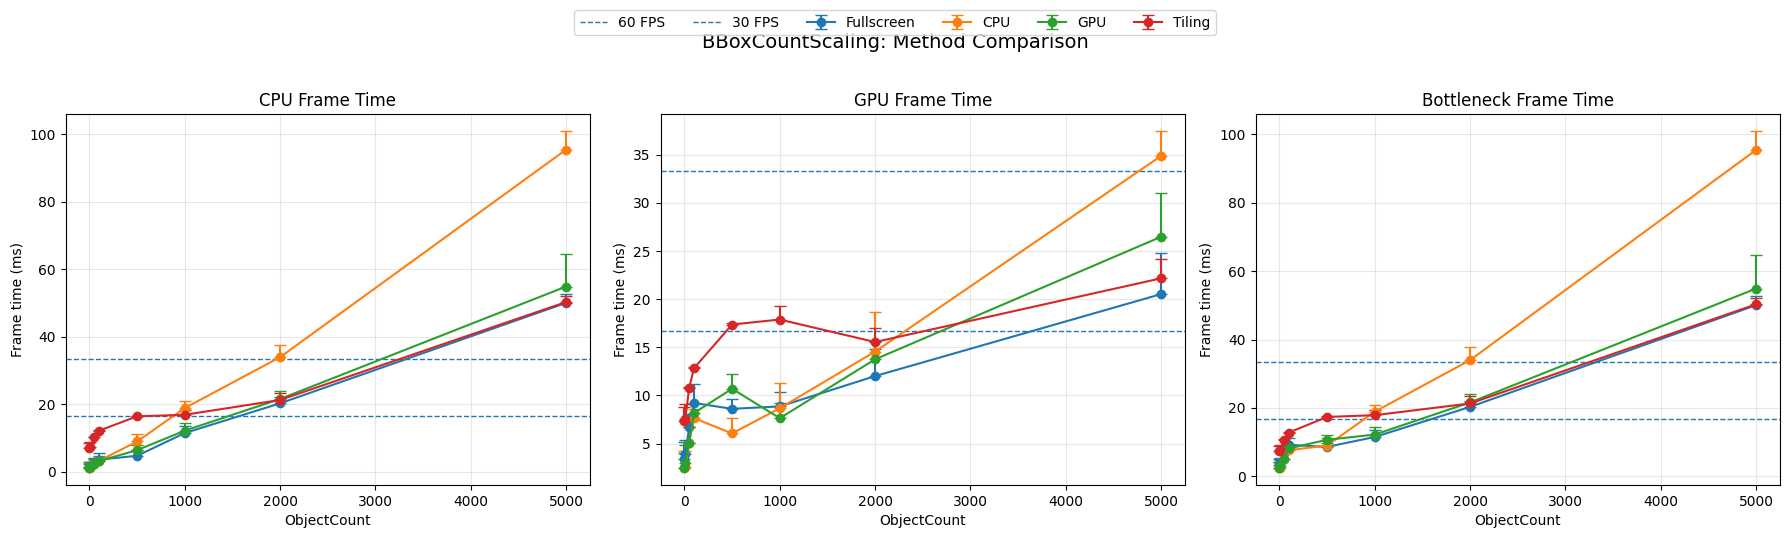

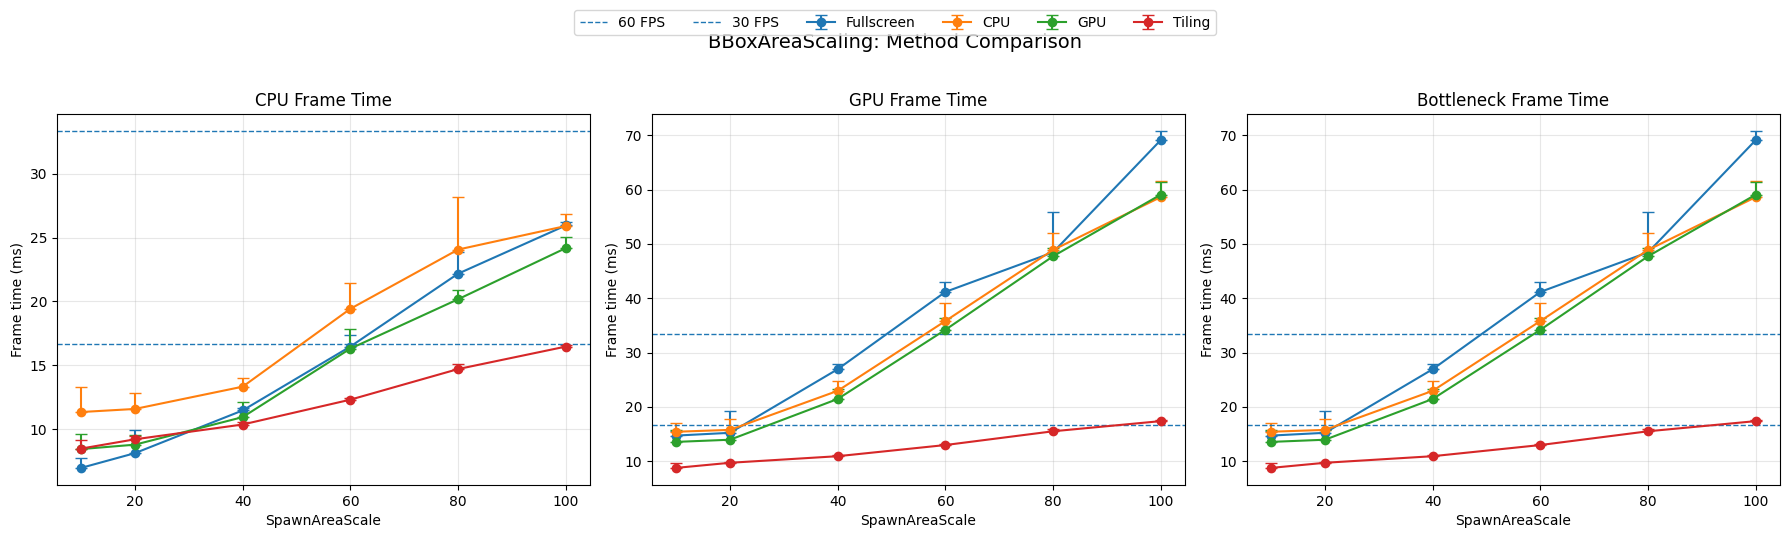

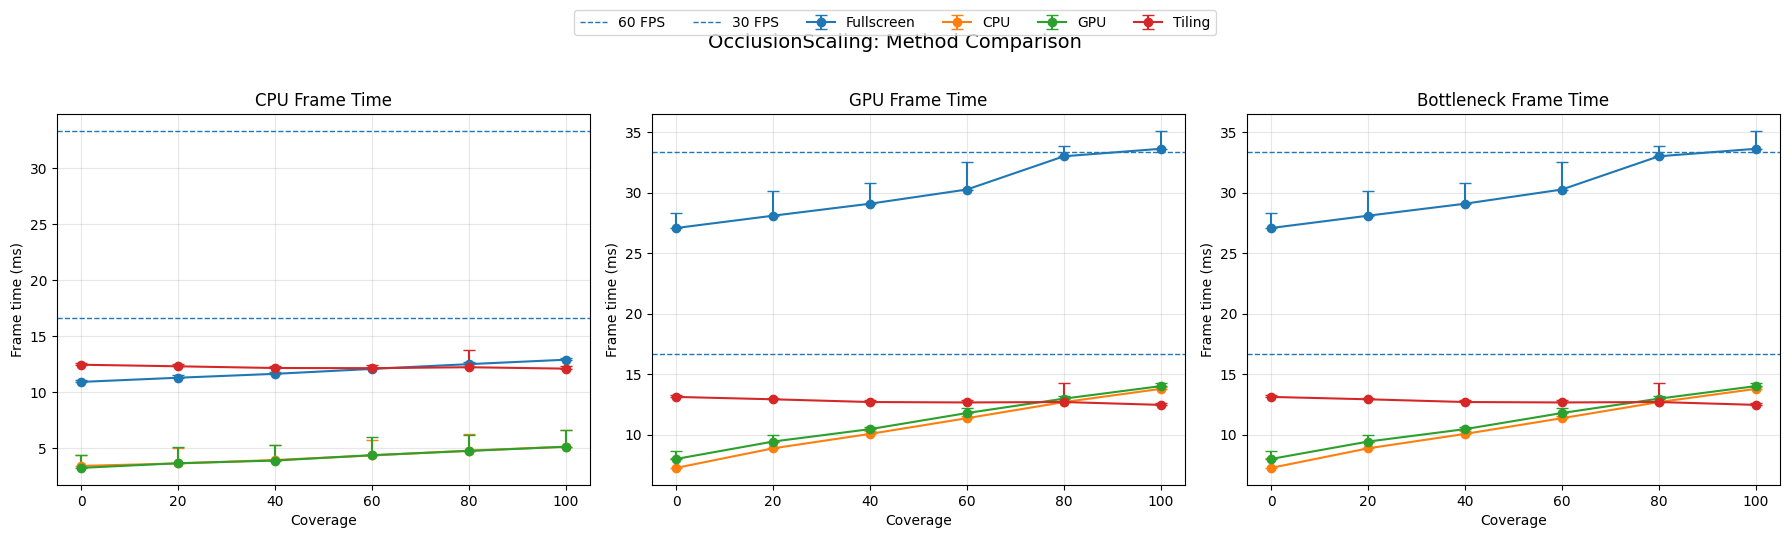

In [283]:
plot_method_graph_row(df, family="AreaScaling", variable="Coverage")
plot_method_graph_row(df, family="StackedStylesScaling", variable="StylesPerObject")
plot_method_graph_row(df, family="BBoxCountScaling", variable="ObjectCount")
# plot_method_graph_row(df, family="BBoxCountScaling", variable="ObjectCount", style_variant="RandomSingleStyle")
plot_method_graph_row(df, family="BBoxAreaScaling", variable="SpawnAreaScale")
# plot_method_graph_row(df, family="BBoxAreaScaling", variable="SpawnAreaScale", style_variant="RandomSingleStyle")
plot_method_graph_row(df, family="OcclusionScaling", variable="Coverage")

### MERGE ABLATIONS

In [ ]:
df["ablation_family"] = (
    df["base_test_name"]
    .astype(str)
    .str.replace(r"_CPU$", "", regex=True)
    .str.replace(r"_GPU$", "", regex=True)
)

merge_df = df[df["merge"].notna()].copy()

merge_df

,test_name,scene,variable,value,render_mode,N,K,styles_per_object,mean_cpu_ms,median_cpu_ms,...,max_gpu_ms,std_gpu_ms,base_test_name,merge,occlusion,style_variant,shader_variant,merge_label,occlusion_label,ablation_family
137,BBoxCountScaling_SameStyle_CPU_NoMerge,TestScene_Spawner,ObjectCount,500,CPU,1,1,1,5.369073,4.808208,...,17.459791,1.581122,BBoxCountScaling_CPU,False,None,SameStyle,Default,NoMerge,NaN,BBoxCountScaling
138,BBoxCountScaling_SameStyle_CPU_NoMerge,TestScene_Spawner,ObjectCount,50,CPU,1,1,1,2.428563,2.215875,...,7.070125,0.807248,BBoxCountScaling_CPU,False,None,SameStyle,Default,NoMerge,NaN,BBoxCountScaling
139,BBoxCountScaling_SameStyle_CPU_NoMerge,TestScene_Spawner,ObjectCount,10,CPU,1,1,1,1.506554,1.359146,...,4.927875,0.704290,BBoxCountScaling_CPU,False,None,SameStyle,Default,NoMerge,NaN,BBoxCountScaling
140,BBoxCountScaling_SameStyle_CPU_NoMerge,TestScene_Spawner,ObjectCount,100,CPU,1,1,1,3.293034,2.993480,...,12.096124,0.902561,BBoxCountScaling_CPU,False,None,SameStyle,Default,NoMerge,NaN,BBoxCountScaling
141,BBoxCountScaling_SameStyle_CPU_NoMerge,TestScene_Spawner,ObjectCount,1000,CPU,1,1,1,86.426428,15.993667,...,78.710624,5.379684,BBoxCountScaling_CPU,False,None,SameStyle,Default,NoMerge,NaN,BBoxCountScaling
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,BBoxAreaScaling_RandomSingleStyle_GPU_Merge,TestScene_Spawner,SpawnAreaScale,60,GPU,32,32,1,7.874997,7.806917,...,7.492125,0.661207,BBoxAreaScaling_GPU,True,None,RandomSingleStyle,Default,Merge,NaN,BBoxAreaScaling
536,BBoxAreaScaling_RandomSingleStyle_GPU_Merge,TestScene_Spawner,SpawnAreaScale,80,GPU,32,32,1,8.466646,8.472688,...,8.208208,0.490682,BBoxAreaScaling_GPU,True,None,RandomSingleStyle,Default,Merge,NaN,BBoxAreaScaling
537,BBoxAreaScaling_RandomSingleStyle_GPU_Merge,TestScene_Spawner,SpawnAreaScale,40,GPU,32,32,1,7.897029,7.797979,...,9.293874,0.886130,BBoxAreaScaling_GPU,True,None,RandomSingleStyle,Default,Merge,NaN,BBoxAreaScaling
538,BBoxAreaScaling_RandomSingleStyle_GPU_Merge,TestScene_Spawner,SpawnAreaScale,10,GPU,32,32,1,7.672585,7.590021,...,7.581583,0.919390,BBoxAreaScaling_GPU,True,None,RandomSingleStyle,Default,Merge,NaN,BBoxAreaScaling


In [ ]:
def plot_merge_ablation_row_combined(
    df,
    base_test_name,
    variable,
    shader_variant=None,
    title=None,
):
    subset = df[
        (df["ablation_family"] == base_test_name) &
        (df["variable"] == variable) &
        (df["render_mode"].isin(["CPU", "GPU"])) &
        (df["merge"].notna())
    ].copy()

    if shader_variant is not None:
        subset = subset[subset["shader_variant"] == shader_variant]

    if subset.empty:
        print("No merge ablation data.")
        return

    # collapse duplicates
    subset = (
        subset
        .groupby(["value", "render_mode", "merge_label"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "render_mode", "merge_label"])
    )

    # ---- 3 PANELS ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    panels = [
        ("cpu", "CPU Frame Time"),
        ("gpu", "GPU Frame Time"),
        ("bottleneck", "Bottleneck Frame Time"),
    ]

    color_map = {
        "CPU": "tab:blue",
        "GPU": "tab:orange"
    }

    linestyle_map = {
        "NoMerge": "-",
        "Merge": "--"
    }

    for ax, (metric, panel_title) in zip(axes, panels):

        for render_mode in ["CPU", "GPU"]:
            for merge_label in ["NoMerge", "Merge"]:

                line_df = subset[
                    (subset["render_mode"] == render_mode) &
                    (subset["merge_label"] == merge_label)
                ].sort_values("value")

                if line_df.empty:
                    continue

                x = line_df["value"].values

                # ---- SELECT METRIC ----
                if metric == "cpu":
                    median = line_df["median_cpu_ms"].values
                    p95 = line_df["p95_cpu_ms"].values

                elif metric == "gpu":
                    median = line_df["median_gpu_ms"].values
                    p95 = line_df["p95_gpu_ms"].values

                else:  # bottleneck
                    cpu_med = line_df["median_cpu_ms"].values
                    gpu_med = line_df["median_gpu_ms"].values
                    cpu_p95 = line_df["p95_cpu_ms"].values
                    gpu_p95 = line_df["p95_gpu_ms"].values

                    median = np.maximum(cpu_med, gpu_med)
                    p95 = np.maximum(cpu_p95, gpu_p95)

                lower_err = np.zeros_like(median)
                upper_err = p95 - median

                ax.errorbar(
                    x,
                    median,
                    yerr=[lower_err, upper_err],
                    marker="o",
                    capsize=4,
                    color=color_map[render_mode],
                    linestyle=linestyle_map[merge_label],
                    label=f"{render_mode} / {merge_label}"
                )

        # frame budget
        ax.axhline(16.67, linestyle="--", linewidth=1, color="gray")
        ax.axhline(33.33, linestyle="--", linewidth=1, color="gray")

        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("Frame time (ms)")
        ax.grid(True, alpha=0.3)

    if title is None:
        title = f"{base_test_name}: Merge Ablation"
        if shader_variant:
            title += f" ({shader_variant})"

    fig.suptitle(title, y=1.02, fontsize=14)

    # single shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.show()

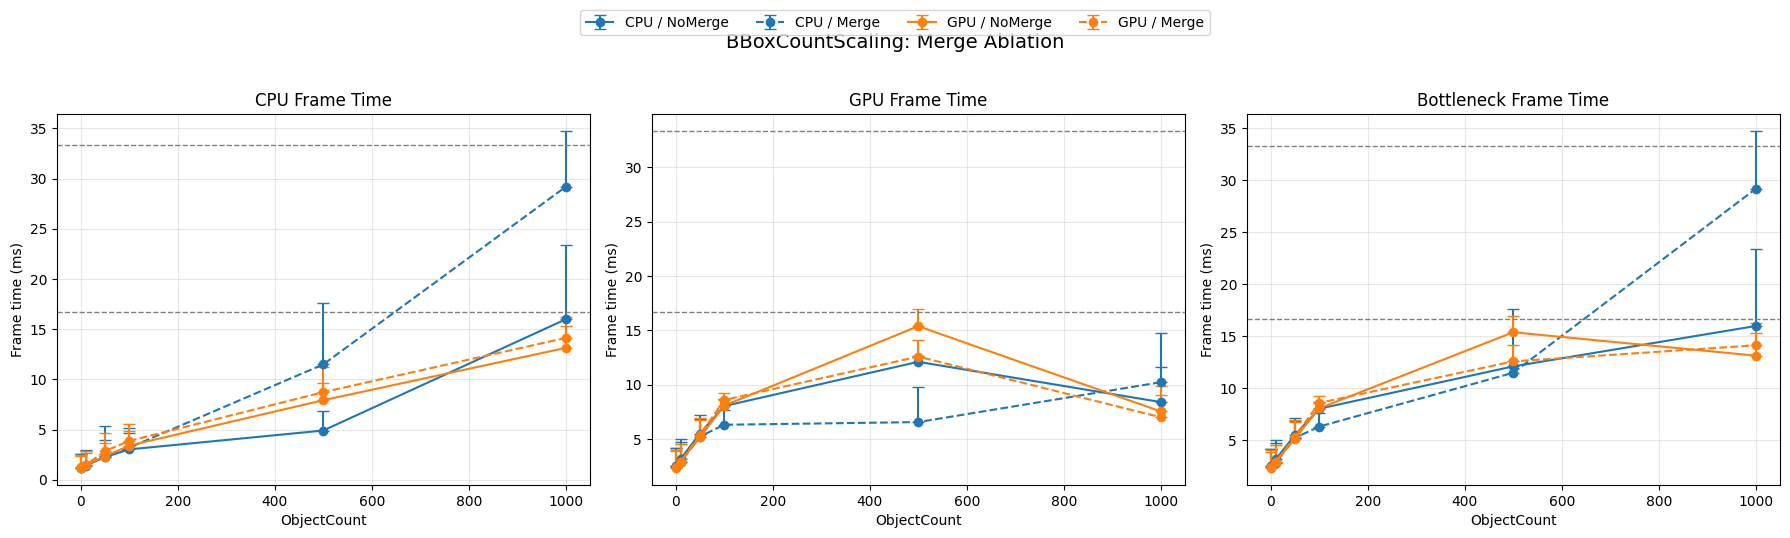

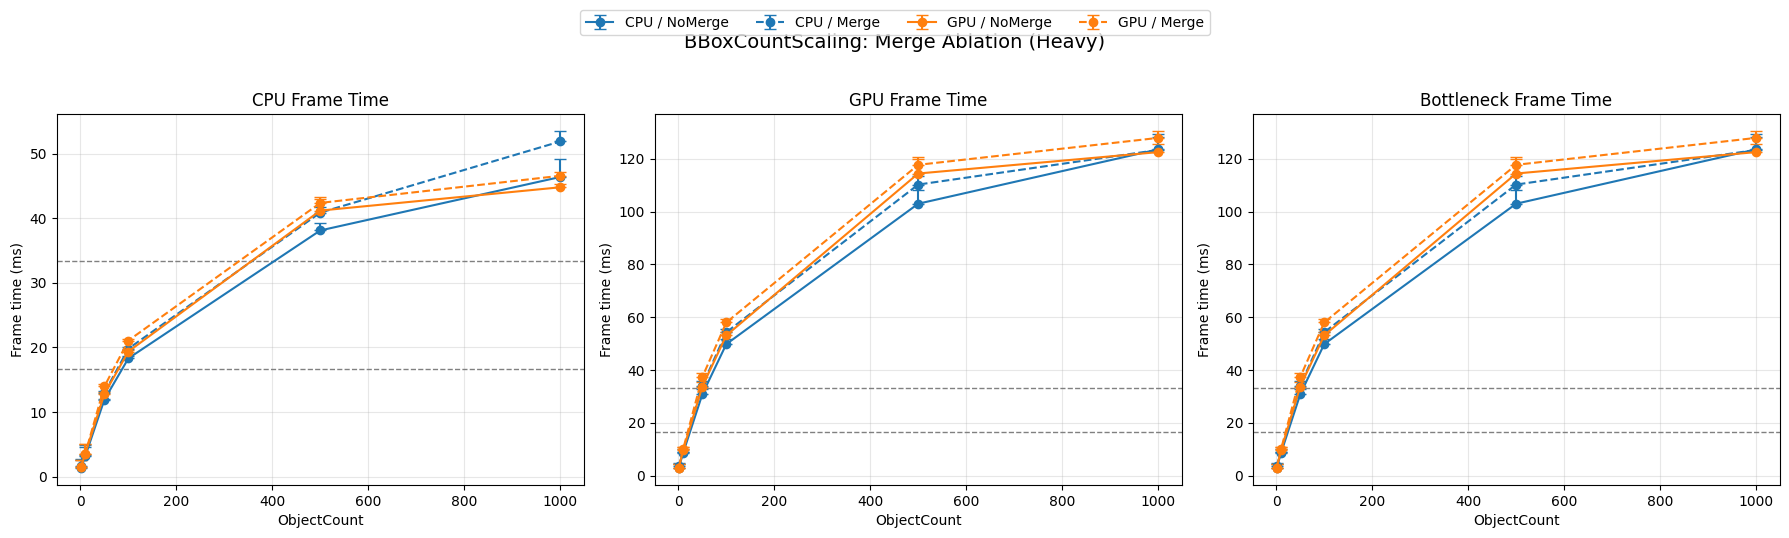

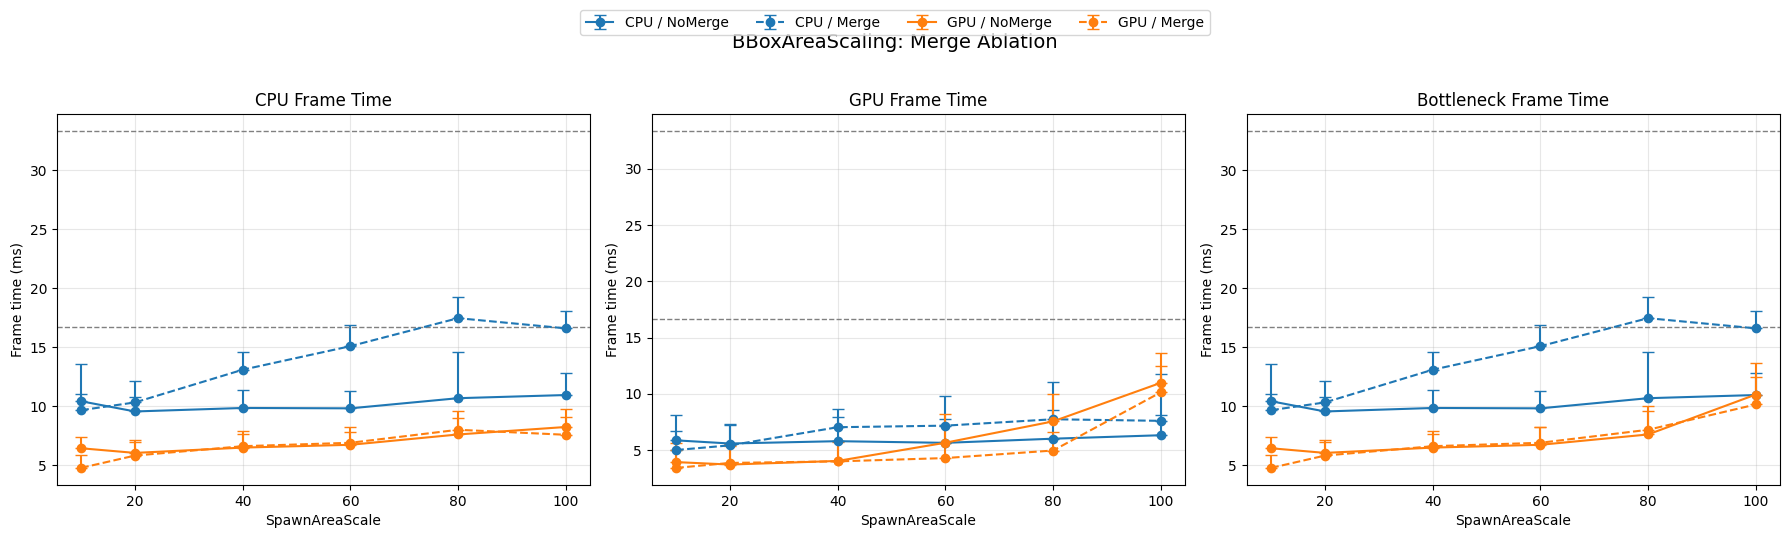

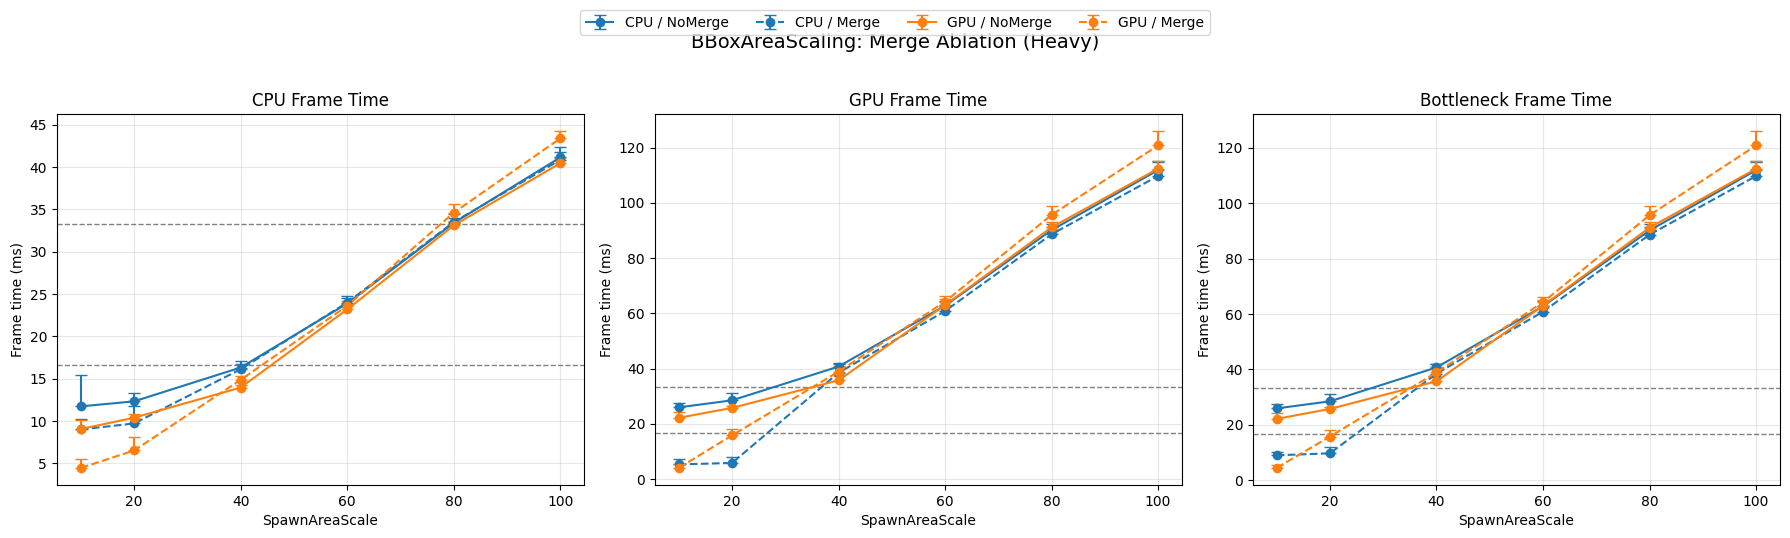

In [ ]:
plot_merge_ablation_row_combined(merge_df, "BBoxCountScaling", "ObjectCount")

plot_merge_ablation_row_combined(
    merge_df,
    "BBoxCountScaling",
    "ObjectCount",
    shader_variant="Heavy"
)

plot_merge_ablation_row_combined(merge_df, "BBoxAreaScaling", "SpawnAreaScale")

plot_merge_ablation_row_combined(
    merge_df,
    "BBoxAreaScaling",
    "SpawnAreaScale",
    shader_variant="Heavy"
)

### Occlusion Ablation

In [ ]:
occlusion_df = df[df["occlusion"].notna()].copy()

occlusion_df

,test_name,scene,variable,value,render_mode,N,K,styles_per_object,mean_cpu_ms,median_cpu_ms,...,max_gpu_ms,std_gpu_ms,base_test_name,merge,occlusion,style_variant,shader_variant,merge_label,occlusion_label,ablation_family
558,OcclusionScaling_RandomSingleStyle_CPU_NoOcclu...,TestScene_Occlusion,Coverage,80,CPU,32,32,1,5.369165,5.005001,...,23.594291,1.108943,OcclusionScaling_CPU,None,False,RandomSingleStyle,Default,NaN,NoOcclusion,OcclusionScaling
559,OcclusionScaling_RandomSingleStyle_CPU_NoOcclu...,TestScene_Occlusion,Coverage,40,CPU,32,32,1,4.459086,4.187187,...,10.926583,0.657427,OcclusionScaling_CPU,None,False,RandomSingleStyle,Default,NaN,NoOcclusion,OcclusionScaling
560,OcclusionScaling_RandomSingleStyle_CPU_NoOcclu...,TestScene_Occlusion,Coverage,20,CPU,32,32,1,4.121109,3.912917,...,9.710916,0.694167,OcclusionScaling_CPU,None,False,RandomSingleStyle,Default,NaN,NoOcclusion,OcclusionScaling
561,OcclusionScaling_RandomSingleStyle_CPU_NoOcclu...,TestScene_Occlusion,Coverage,60,CPU,32,32,1,5.046183,4.736125,...,12.922666,0.533858,OcclusionScaling_CPU,None,False,RandomSingleStyle,Default,NaN,NoOcclusion,OcclusionScaling
562,OcclusionScaling_RandomSingleStyle_CPU_NoOcclu...,TestScene_Occlusion,Coverage,100,CPU,32,32,1,6.089188,5.667167,...,16.935833,0.554264,OcclusionScaling_CPU,None,False,RandomSingleStyle,Default,NaN,NoOcclusion,OcclusionScaling
563,OcclusionScaling_RandomSingleStyle_CPU_NoOcclu...,TestScene_Occlusion,Coverage,0,CPU,32,32,1,3.681812,3.493355,...,8.504000,0.917095,OcclusionScaling_CPU,None,False,RandomSingleStyle,Default,NaN,NoOcclusion,OcclusionScaling
564,OcclusionScaling_RandomSingleStyle_CPU_Occlusion,TestScene_Occlusion,Coverage,80,CPU,32,32,1,15.052885,15.056396,...,41.988083,1.145181,OcclusionScaling_CPU,None,True,RandomSingleStyle,Default,NaN,Occlusion,OcclusionScaling
565,OcclusionScaling_RandomSingleStyle_CPU_Occlusion,TestScene_Occlusion,Coverage,40,CPU,32,32,1,14.655066,14.552521,...,41.051000,1.553895,OcclusionScaling_CPU,None,True,RandomSingleStyle,Default,NaN,Occlusion,OcclusionScaling
566,OcclusionScaling_RandomSingleStyle_CPU_Occlusion,TestScene_Occlusion,Coverage,20,CPU,32,32,1,14.525814,14.496646,...,41.367625,1.127754,OcclusionScaling_CPU,None,True,RandomSingleStyle,Default,NaN,Occlusion,OcclusionScaling
567,OcclusionScaling_RandomSingleStyle_CPU_Occlusion,TestScene_Occlusion,Coverage,60,CPU,32,32,1,14.843177,14.814167,...,41.161625,0.993830,OcclusionScaling_CPU,None,True,RandomSingleStyle,Default,NaN,Occlusion,OcclusionScaling


In [ ]:
def plot_occlusion_ablation_row_combined(
    df,
    base_test_name,
    variable,
    shader_variant=None,
    title=None,
):
    subset = df[
        (df["ablation_family"] == base_test_name) &
        (df["variable"] == variable) &
        (df["render_mode"].isin(["CPU", "GPU"])) &
        (df["occlusion"].notna())
    ].copy()

    if shader_variant is not None:
        subset = subset[subset["shader_variant"] == shader_variant]

    if subset.empty:
        print("No occlusion ablation data.")
        return

    subset = (
        subset
        .groupby(["value", "render_mode", "occlusion_label"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "render_mode", "occlusion_label"])
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    panels = [
        ("cpu", "CPU Frame Time"),
        ("gpu", "GPU Frame Time"),
        ("bottleneck", "Bottleneck Frame Time"),
    ]

    color_map = {
        "CPU": "tab:blue",
        "GPU": "tab:orange"
    }

    linestyle_map = {
        "NoOcclusion": "-",
        "Occlusion": "--"
    }

    for ax, (metric, panel_title) in zip(axes, panels):
        for render_mode in ["CPU", "GPU"]:
            for occlusion_label in ["NoOcclusion", "Occlusion"]:
                line_df = subset[
                    (subset["render_mode"] == render_mode) &
                    (subset["occlusion_label"] == occlusion_label)
                ].sort_values("value")

                if line_df.empty:
                    continue

                x = line_df["value"].values

                if metric == "cpu":
                    median = line_df["median_cpu_ms"].values
                    p95 = line_df["p95_cpu_ms"].values
                elif metric == "gpu":
                    median = line_df["median_gpu_ms"].values
                    p95 = line_df["p95_gpu_ms"].values
                else:
                    cpu_med = line_df["median_cpu_ms"].values
                    gpu_med = line_df["median_gpu_ms"].values
                    cpu_p95 = line_df["p95_cpu_ms"].values
                    gpu_p95 = line_df["p95_gpu_ms"].values
                    median = np.maximum(cpu_med, gpu_med)
                    p95 = np.maximum(cpu_p95, gpu_p95)

                lower_err = np.zeros_like(median)
                upper_err = p95 - median

                ax.errorbar(
                    x,
                    median,
                    yerr=[lower_err, upper_err],
                    marker="o",
                    capsize=4,
                    color=color_map[render_mode],
                    linestyle=linestyle_map[occlusion_label],
                    label=f"{render_mode} / {occlusion_label}"
                )

        ax.axhline(16.67, linestyle="--", linewidth=1, color="gray")
        ax.axhline(33.33, linestyle="--", linewidth=1, color="gray")
        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("Frame time (ms)")
        ax.grid(True, alpha=0.3)

    if title is None:
        title = f"{base_test_name}: Occlusion Ablation"
        if shader_variant:
            title += f" ({shader_variant})"

    fig.suptitle(title, y=1.02, fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))
    plt.tight_layout()
    plt.show()

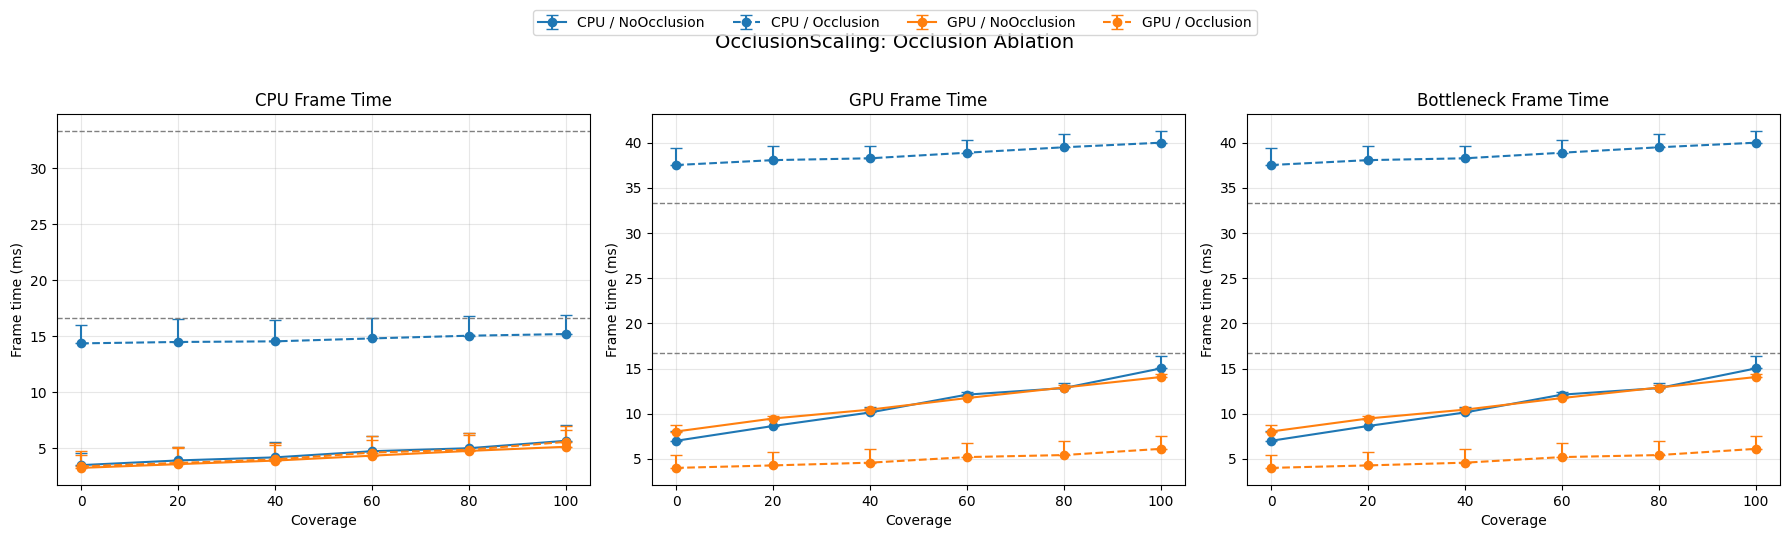

In [ ]:
plot_occlusion_ablation_row_combined(
    df,
    base_test_name="OcclusionScaling",
    variable="Coverage"
)

plot_occlusion_ablation_row_combined(
    df,
    base_test_name="OcclusionScaling",
    variable="Coverage",
    

### Tiling Ablation

In [ ]:
tiling_ablation_df = df.copy()

# detect explicit tile-size ablation rows from test_name
tiling_ablation_df["tile_size"] = (
    tiling_ablation_df["test_name"]
    .astype(str)
    .str.extract(r"Tiling(8|16|32|64)$")[0]
)

tiling_ablation_df["tile_size"] = pd.to_numeric(
    tiling_ablation_df["tile_size"],
    errors="coerce"
)

# only the tile-size ablation rows
tiling_ablation_df = tiling_ablation_df[tiling_ablation_df["tile_size"].notna()].copy()

# make a family that ignores the specific tile size suffix
tiling_ablation_df["tiling_family"] = (
    tiling_ablation_df["base_test_name"]
    .astype(str)
    .str.replace(r"_Tiling(8|16|32|64)$", "", regex=True)
    .str.replace(r"_Tiling$", "", regex=True)
)

In [ ]:
def plot_tiling_ablation_row(
    df,
    family,
    variable,
    title_prefix=None,
    style_variant=None,
    shader_variant=None,
):
    subset = df[
        (df["tiling_family"] == family) &
        (df["variable"] == variable)
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if shader_variant is not None:
        subset = subset[subset["shader_variant"] == shader_variant]

    if subset.empty:
        print(f"No tiling ablation data for family='{family}', variable='{variable}'.")
        return

    subset = (
        subset
        .groupby(["value", "tile_size"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "tile_size"])
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    panels = [
        ("cpu", "CPU Frame Time"),
        ("gpu", "GPU Frame Time"),
        ("bottleneck", "Bottleneck Frame Time"),
    ]

    tile_sizes = [8, 16, 32, 64]

    for ax, (metric, panel_title) in zip(axes, panels):
        for tile_size in tile_sizes:
            mode_df = subset[subset["tile_size"] == tile_size].sort_values("value")
            if mode_df.empty:
                continue

            x = mode_df["value"].values

            if metric == "cpu":
                median = mode_df["median_cpu_ms"].values
                p95 = mode_df["p95_cpu_ms"].values
            elif metric == "gpu":
                median = mode_df["median_gpu_ms"].values
                p95 = mode_df["p95_gpu_ms"].values
            else:
                cpu_med = mode_df["median_cpu_ms"].values
                gpu_med = mode_df["median_gpu_ms"].values
                cpu_p95 = mode_df["p95_cpu_ms"].values
                gpu_p95 = mode_df["p95_gpu_ms"].values

                median = np.maximum(cpu_med, gpu_med)
                p95 = np.maximum(cpu_p95, gpu_p95)

            lower_err = np.zeros_like(median)
            upper_err = p95 - median

            ax.errorbar(
                x,
                median,
                yerr=[lower_err, upper_err],
                marker="o",
                capsize=4,
                label=f"Tiling {tile_size}"
            )

        ax.axhline(16.67, linestyle="--", linewidth=1)
        ax.axhline(33.33, linestyle="--", linewidth=1)
        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("Frame time (ms)")
        ax.grid(True, alpha=0.3)

    if title_prefix is None:
        title_prefix = family

    fig.suptitle(f"{title_prefix}: Tile Size Ablation", y=1.02, fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.08))
    plt.tight_layout()
    plt.show()

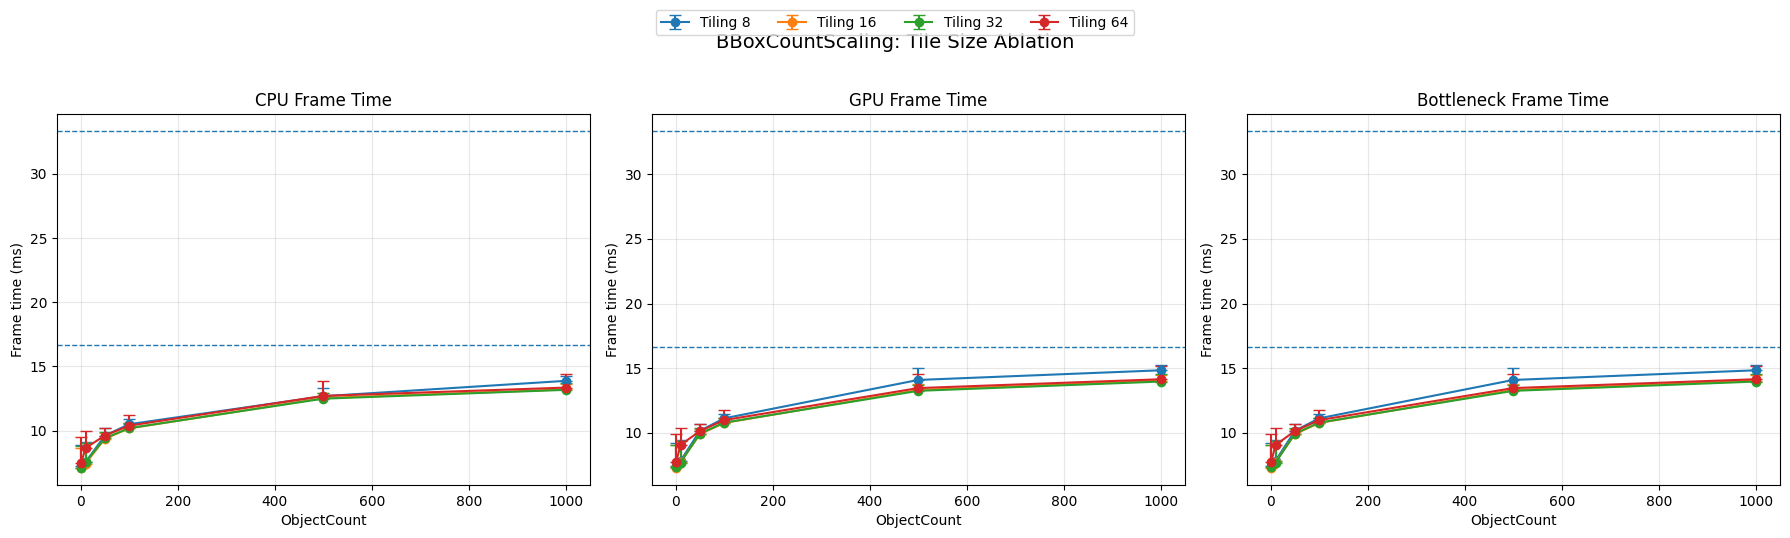

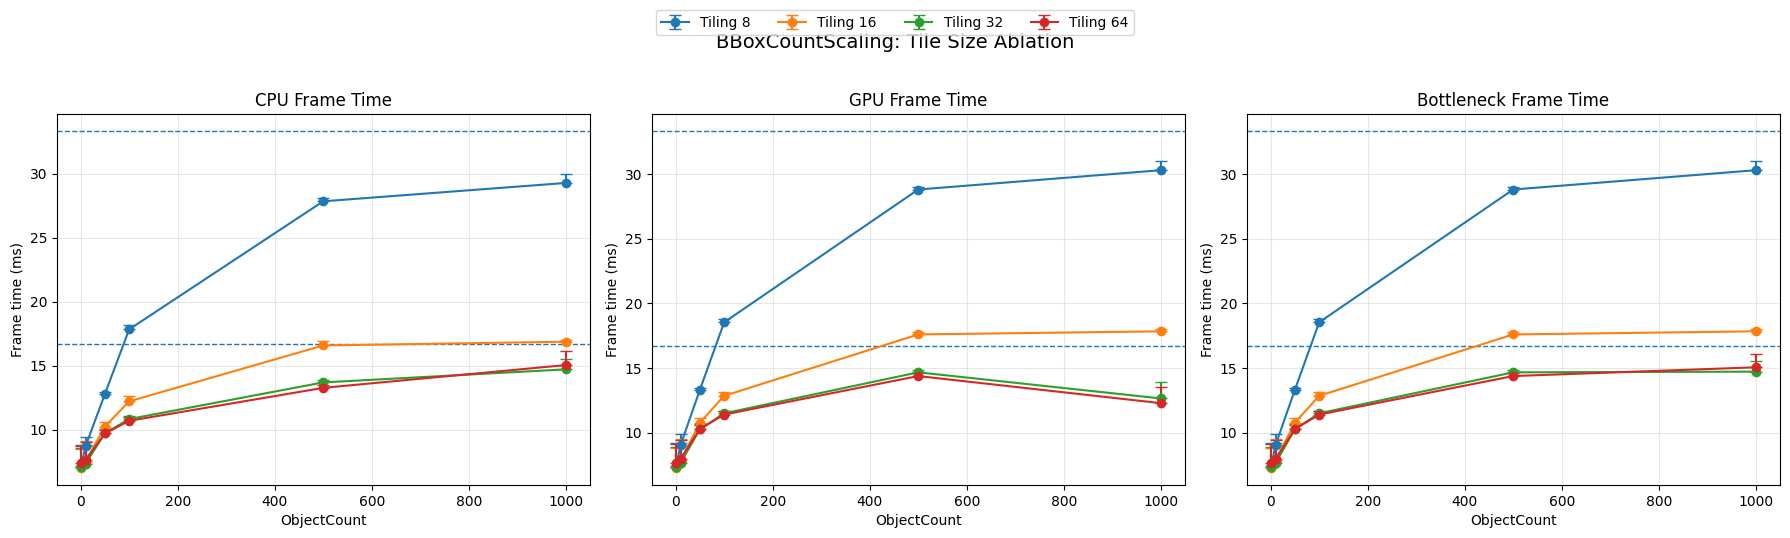

In [ ]:
plot_tiling_ablation_row(
    tiling_ablation_df,
    family="BBoxCountScaling",
    variable="ObjectCount",
    style_variant="SameStyle"
)

plot_tiling_ablation_row(
    tiling_ablation_df,
    family="BBoxCountScaling",
    variable="ObjectCount",
    style_variant="RandomSingleStyle"
)

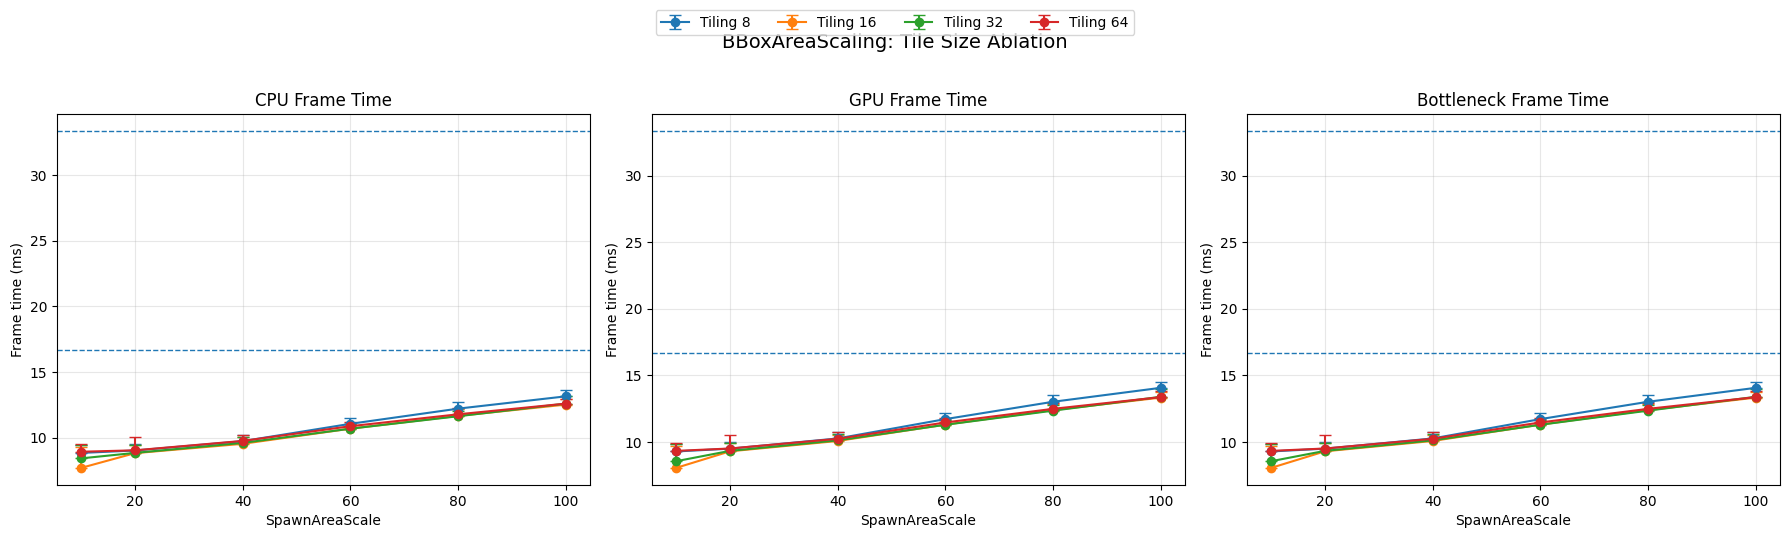

In [ ]:
plot_tiling_ablation_row(
    tiling_ablation_df,
    family="BBoxAreaScaling",
    variable="SpawnAreaScale",
    style_variant="SameStyle"
)

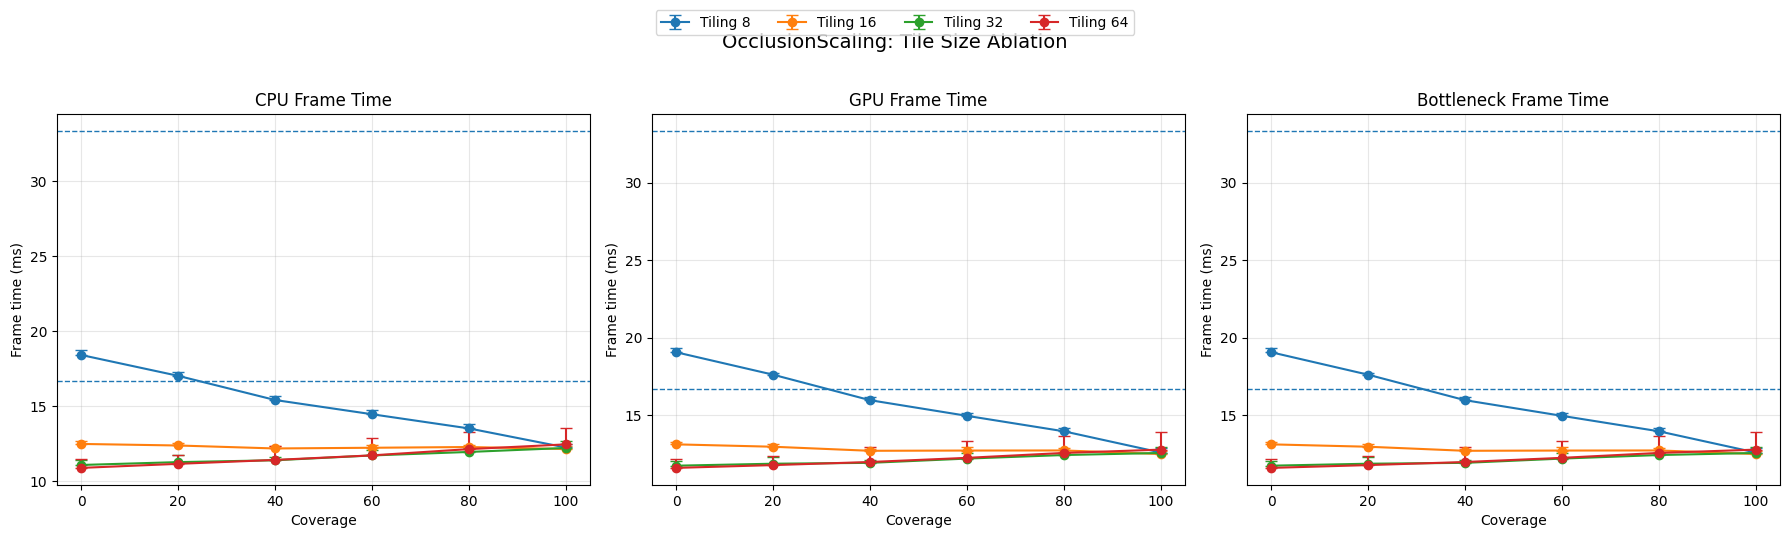

In [ ]:
plot_tiling_ablation_row(
    tiling_ablation_df,
    family="OcclusionScaling",
    variable="Coverage",
    style_variant="RandomSingleStyle",
)

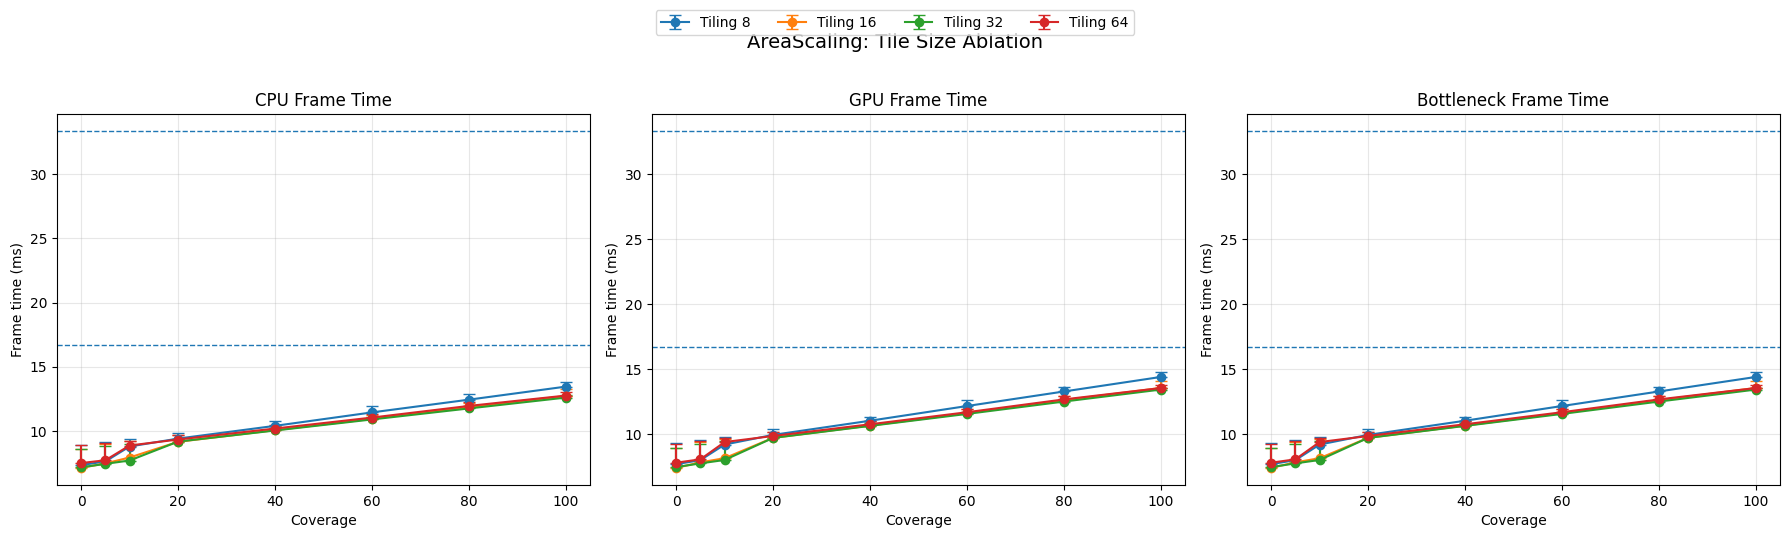

In [ ]:
plot_tiling_ablation_row(
    tiling_ablation_df,
    family="AreaScaling",
    variable="Coverage",
    style_variant="SameStyle",
)